In [1]:
# =========================================================
# STEP 1 - Data Collection & Wrangling
# Run this in Jupyter Notebook (Coursera Labs / Colab / local)
# =========================================================
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
df = pd.read_csv(url)

# --- Inspect ---
print("Shape:", df.shape)
print(df.info())
print(df.isna().sum())          # check missing values
print(df.describe())

# --- Clean ---
df['Date'] = pd.to_datetime(df['Date'])          # consistent date format
df = df.dropna(subset=['Automobile_Sales'])      # drop rows with no sales value
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# --- Save cleaned version so the next steps can reuse it ---
df.to_csv("clean_automobile_sales.csv", index=False)
print("Saved clean_automobile_sales.csv with", df.shape[0], "rows")

Shape: (528, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     528 non-null    object 
 1   Year                     528 non-null    int64  
 2   Month                    528 non-null    object 
 3   Recession                528 non-null    int64  
 4   Consumer_Confidence      528 non-null    float64
 5   Seasonality_Weight       528 non-null    float64
 6   Price                    528 non-null    float64
 7   Advertising_Expenditure  528 non-null    int64  
 8   Competition              528 non-null    int64  
 9   GDP                      528 non-null    float64
 10  Growth_Rate              528 non-null    float64
 11  unemployment_rate        528 non-null    float64
 12  Automobile_Sales         528 non-null    float64
 13  Vehicle_Type             528 non-null    object 
 14  City     

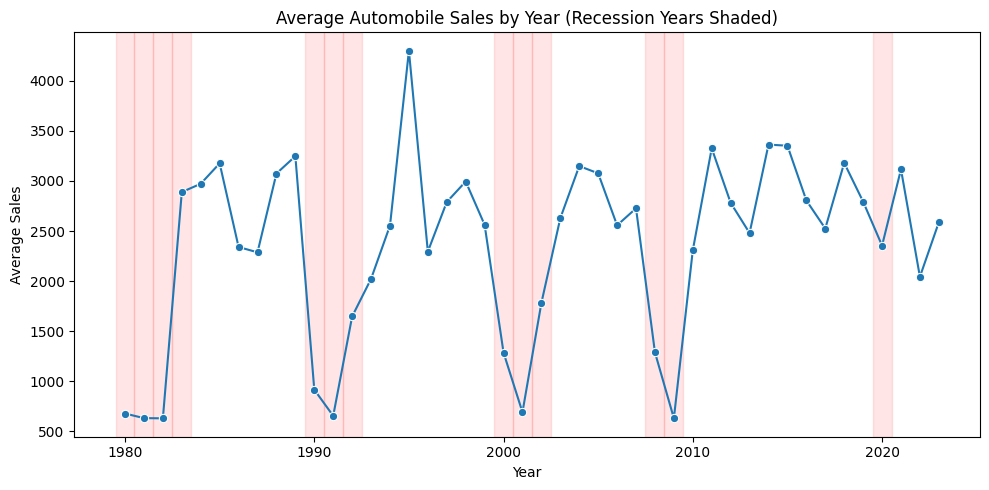

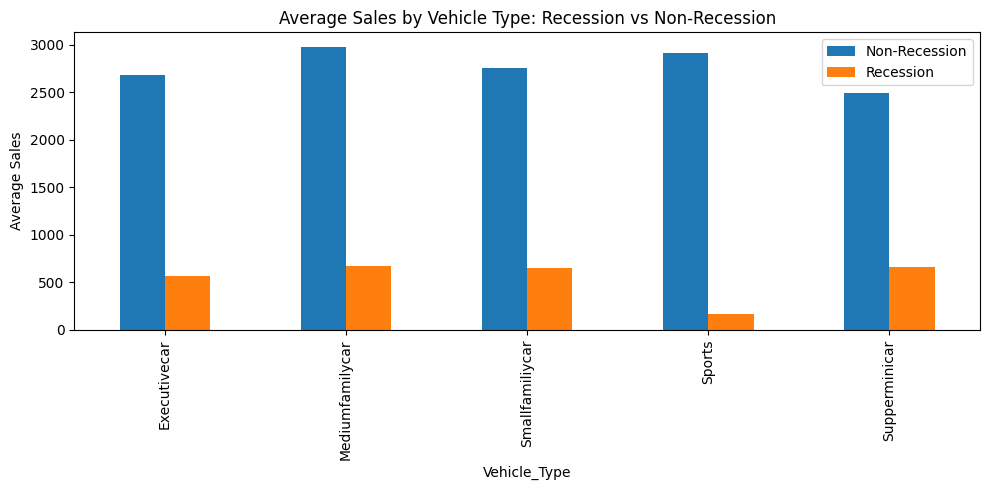

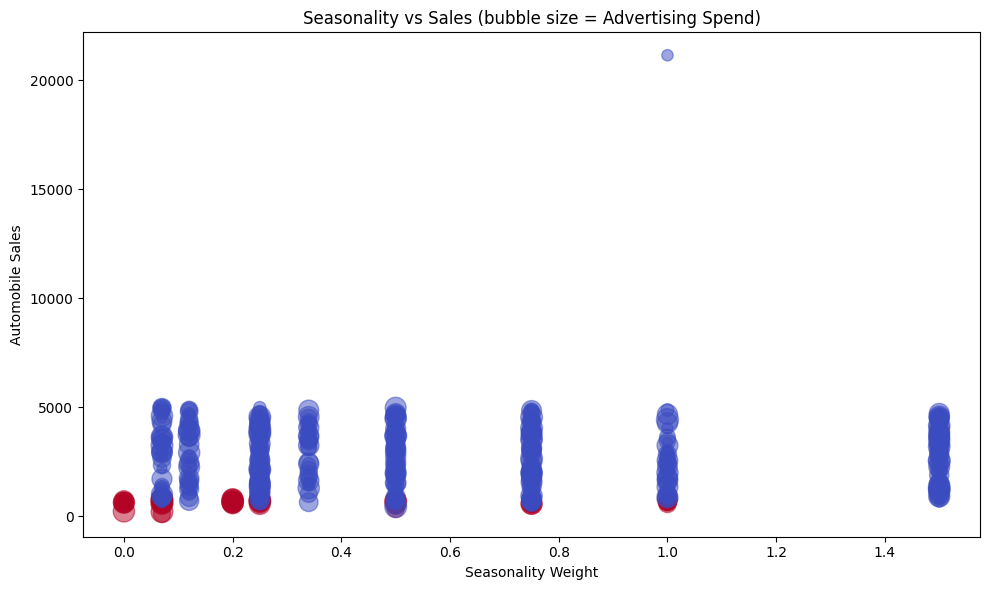

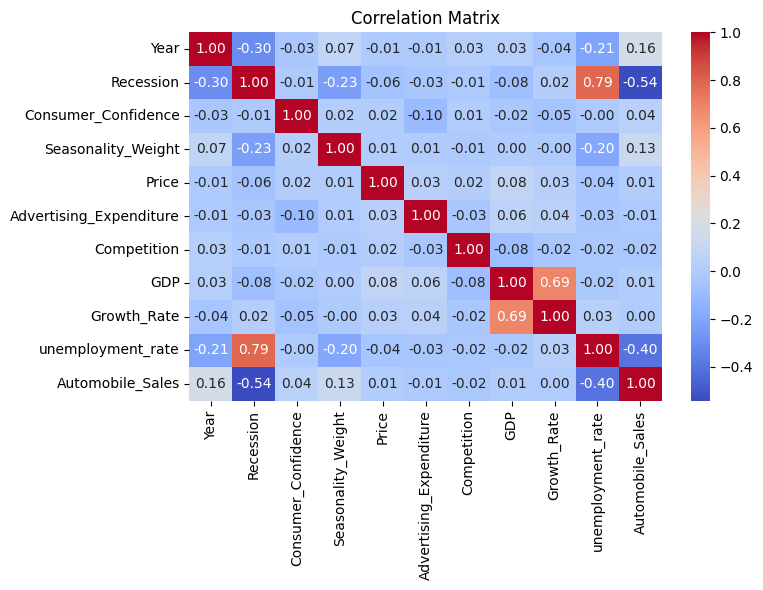

EDA charts saved. Use the exact numbers printed below in your report:
Recession                  0           1
Vehicle_Type                            
Executivecar     2686.436232  564.000000
Mediumfamilycar  2981.501935  674.847619
Smallfamiliycar  2752.658140  650.733333
Sports           2910.636264  170.333333
Supperminicar    2495.242222  659.270968

Correlation with Automobile_Sales:
 Automobile_Sales           1.000000
Year                       0.164813
Seasonality_Weight         0.125765
Consumer_Confidence        0.037485
GDP                        0.014335
Price                      0.012052
Growth_Rate                0.002140
Advertising_Expenditure   -0.013854
Competition               -0.018954
unemployment_rate         -0.398008
Recession                 -0.541000
Name: Automobile_Sales, dtype: float64


In [2]:
# =========================================================
# STEP 2 - EDA and Data Visualization
# (run after step 1, or re-load clean_automobile_sales.csv)
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clean_automobile_sales.csv")

# 1) Line plot: yearly sales trend, recession years highlighted
yearly = df.groupby('Year')['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x='Year', y='Automobile_Sales', marker='o')
recession_years = df[df['Recession'] == 1]['Year'].unique()
for y in recession_years:
    plt.axvspan(y - 0.5, y + 0.5, color='red', alpha=0.1)
plt.title("Average Automobile Sales by Year (Recession Years Shaded)")
plt.xlabel("Year"); plt.ylabel("Average Sales")
plt.tight_layout()
plt.savefig("chart_yearly_sales.png", dpi=150)
plt.show()

# 2) Bar chart: sales by vehicle type during recession vs non-recession
by_type = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().unstack()
by_type.plot(kind='bar', figsize=(10, 5))
plt.title("Average Sales by Vehicle Type: Recession vs Non-Recession")
plt.ylabel("Average Sales")
plt.legend(['Non-Recession', 'Recession'])
plt.tight_layout()
plt.savefig("chart_vehicle_type_recession.png", dpi=150)
plt.show()

# 3) Bubble plot: seasonality weight vs sales, sized by advertising spend
plt.figure(figsize=(10, 6))
plt.scatter(df['Seasonality_Weight'], df['Automobile_Sales'],
            s=df['Advertising_Expenditure'] / 20, alpha=0.5, c=df['Recession'], cmap='coolwarm')
plt.xlabel("Seasonality Weight"); plt.ylabel("Automobile Sales")
plt.title("Seasonality vs Sales (bubble size = Advertising Spend)")
plt.tight_layout()
plt.savefig("chart_seasonality_bubble.png", dpi=150)
plt.show()

# 4) Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("chart_correlation_heatmap.png", dpi=150)
plt.show()

print("EDA charts saved. Use the exact numbers printed below in your report:")
print(by_type)
print("\nCorrelation with Automobile_Sales:\n", numeric_cols.corr()['Automobile_Sales'].sort_values(ascending=False))

In [3]:
# =========================================================
# STEP 3 - EDA with SQL
# Loads the cleaned data into an in-memory SQLite DB so you can
# run real SQL queries against it (as the assignment requires).
# =========================================================
import pandas as pd
import sqlite3

df = pd.read_csv("clean_automobile_sales.csv")

conn = sqlite3.connect(":memory:")
df.to_sql("AutoSales", conn, index=False, if_exists="replace")

queries = {
    "Total sales by vehicle type during recessions": """
        SELECT Vehicle_Type, ROUND(SUM(Automobile_Sales), 1) AS Total_Sales
        FROM AutoSales
        WHERE Recession = 1
        GROUP BY Vehicle_Type
        ORDER BY Total_Sales DESC;
    """,
    "Average unemployment rate vs sales by recession status": """
        SELECT Recession, ROUND(AVG(unemployment_rate), 2) AS Avg_Unemployment,
               ROUND(AVG(Automobile_Sales), 1) AS Avg_Sales
        FROM AutoSales
        GROUP BY Recession;
    """,
    "Top 5 highest advertising expenditure months": """
        SELECT Date, Vehicle_Type, Advertising_Expenditure, Automobile_Sales
        FROM AutoSales
        ORDER BY Advertising_Expenditure DESC
        LIMIT 5;
    """,
}

for title, q in queries.items():
    print("\n===", title, "===")
    result = pd.read_sql_query(q, conn)
    print(result)
    # Save each result so you can screenshot/paste real numbers into the report
    result.to_csv(f"sql_result_{title[:20].replace(' ', '_')}.csv", index=False)


=== Total sales by vehicle type during recessions ===
      Vehicle_Type  Total_Sales
0  Mediumfamilycar      28343.6
1  Smallfamiliycar      23426.4
2    Supperminicar      20437.4
3     Executivecar        564.0
4           Sports        511.0

=== Average unemployment rate vs sales by recession status ===
   Recession  Avg_Unemployment  Avg_Sales
0          0              2.00     2816.8
1          1              4.14      648.5

=== Top 5 highest advertising expenditure months ===
         Date     Vehicle_Type  Advertising_Expenditure  Automobile_Sales
0  2012-04-30           Sports                     4983            4423.5
1  2001-07-31  Mediumfamilycar                     4974             651.0
2  2005-10-31           Sports                     4962            3726.7
3  2003-11-30  Mediumfamilycar                     4953            3949.0
4  2017-07-31    Supperminicar                     4953            3676.7


In [4]:
# =========================================================
# STEP 4 - Folium Map
# pip install folium   (if not already installed)
# =========================================================
import pandas as pd
import folium

df = pd.read_csv("clean_automobile_sales.csv")

# Approximate coordinates for the states present in the dataset
state_coords = {
    "California": (36.7, -119.4),
    "New York": (43.0, -75.5),
    "Illinois": (40.0, -89.0),
    "Georgia": (32.6, -83.4),
}

city_sales = df.groupby("City")["Automobile_Sales"].mean().reset_index()

m = folium.Map(location=[39.8, -98.6], zoom_start=4)
for _, row in city_sales.iterrows():
    coords = state_coords.get(row["City"])
    if coords:
        folium.CircleMarker(
            location=coords,
            radius=max(5, row["Automobile_Sales"] / 200),
            popup=f"{row['City']}: avg sales {row['Automobile_Sales']:.1f}",
            color="crimson", fill=True, fill_opacity=0.6,
        ).add_to(m)

m.save("recession_sales_map.html")
print("Map saved as recession_sales_map.html - open it to view, or display `m` directly in Jupyter.")
print(city_sales)

Map saved as recession_sales_map.html - open it to view, or display `m` directly in Jupyter.
         City  Automobile_Sales
0  California       2158.875969
1     Georgia       2400.154050
2    Illinois       2383.641791
3    New York       2457.732639


In [6]:
!pip install dash
# =========================================================
# STEP 5 - Plotly Dash Dashboard
# pip install dash plotly   (if not already installed)
# Run with: python 5_dash_app.py   then open http://127.0.0.1:8050
# =========================================================
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

df = pd.read_csv("clean_automobile_sales.csv")

app = Dash(__name__)

app.layout = html.Div([
    html.H1("Automobile Sales Dashboard - Recession Impact Analysis"),
    dcc.Dropdown(
        id="statistics-dropdown",
        options=[
            {"label": "Recession Period Statistics", "value": "recession"},
            {"label": "Yearly Statistics", "value": "yearly"},
        ],
        value="yearly",
    ),
    dcc.Dropdown(
        id="year-dropdown",
        options=[{"label": y, "value": y} for y in sorted(df["Year"].unique())],
        value=df["Year"].max(),
    ),
    dcc.Graph(id="sales-graph"),
])

@app.callback(
    Output("sales-graph", "figure"),
    Input("statistics-dropdown", "value"),
    Input("year-dropdown", "value"),
)
def update_graph(stat_type, year):
    if stat_type == "recession":
        filtered = df[df["Recession"] == 1]
        fig = px.line(filtered.groupby("Year")["Automobile_Sales"].mean().reset_index(),
                       x="Year", y="Automobile_Sales", title="Average Sales During Recession Periods")
    else:
        filtered = df[df["Year"] == year]
        fig = px.bar(filtered.groupby("Vehicle_Type")["Automobile_Sales"].mean().reset_index(),
                      x="Vehicle_Type", y="Automobile_Sales", title=f"Sales by Vehicle Type in {year}")
    return fig

if __name__ == "__main__":
    app.run(debug=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 56.7 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

In [8]:
# =========================================================
# STEP 6 - Predictive Analysis (Classification)
# Predict whether a given period is a Recession (1) or not (0)
# =========================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

df = pd.read_csv("clean_automobile_sales.csv")

features = ["GDP", "unemployment_rate", "Consumer_Confidence",
            "Advertising_Expenditure", "Price", "Seasonality_Weight"]
X = df[features]
y = df["Recession"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({"Model": name, "Accuracy": round(acc, 3), "F1_Score": round(f1, 3)})
    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds))

results_df = pd.DataFrame(results)
print("\nSummary:\n", results_df)
results_df.to_csv("model_results.csv", index=False)

# Feature importance from the strongest interpretable model (Decision Tree)
importances = pd.Series(models["Decision Tree"].feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importance (which factor predicts recession-driven sales drops best):\n", importances)


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        83
           1       0.96      0.96      0.96        23

    accuracy                           0.98       106
   macro avg       0.97      0.97      0.97       106
weighted avg       0.98      0.98      0.98       106


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        83
           1       1.00      0.91      0.95        23

    accuracy                           0.98       106
   macro avg       0.99      0.96      0.97       106
weighted avg       0.98      0.98      0.98       106


--- SVM ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        83
           1       1.00      0.87      0.93        23

    accuracy                           0.97       106
   macro avg       0.98      0.93      0.96       106
weighted 